# SSY098
## Project 3: Structure-from-Motion in 2D

In this project, you will implement a Structure-from-Motion pipeline in 2D, which is equivalent
to stitching together multiple 2D images of a planar surface.

### AI Usage Statement
<!-- Claude (claude-sonnet-4-6 via Claude Code) was used as an assistant during the completion of this lab. The AI was not used to directly write or generate implementation code, but was consulted for conceptual explanations and debugging guidance throughout the assignment.                          
                       
Specifically, the AI was used to:
  - Explain inverse warping and why target pixel locations are always known independently of the warp
  - Explain affine transformation estimation using np.linalg.lstsq, including why the point matrix must be augmented with ones to solve for translation simultaneously with the linear part        
  - Clarify NumPy concepts such as np.squeeze vs slicing for removing array elements, axis parameter behavior in np.sum, boolean array indexing with ~, and .sum() on boolean arrays                   
  - Debug a cv.warpPerspective dtype error requiring float64 transformation matrices                 
  - Debug an incorrect transformation matrix construction using np.ones instead of np.zeros, causing a corrupted perspective warp
  - Debug a cv.drawMatchesKnn argument error caused by passing coordinate arrays instead of cv.KeyPoint objects
  - Explain RANSAC, including the role of the minimal solver
  - Explain histogram equalization and its role in making SIFT features more comparable across images with different contrast distributions
  - Explain deformable B-spline registration, shrink factors and the coarse-to-fine multi-resolution scheme
                                                                                                     
All implementations were written by me, with the AI serving as an explanatory resource and assistant during debugging. -->

 ## Imports
 

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd
from typing import Tuple, List, Sequence, Union, Optional
import glob
from itertools import combinations, product
from tqdm.auto import tqdm

## Loading Dataset
This section loads the dataset used in this project

In [47]:
bark_paths = sorted(glob.glob('data/bark/*.ppm'))
boat_paths = sorted(glob.glob('data/boat/*.pgm'))
graf_paths = sorted(glob.glob('data/graf/*.ppm'))
wall_paths = sorted(glob.glob('data/wall/*.ppm'))

bark_images = [cv.imread(p, cv.IMREAD_COLOR_RGB) for p in bark_paths]
boat_images = [cv.imread(p, cv.IMREAD_GRAYSCALE) for p in boat_paths]
graf_images = [cv.imread(p, cv.IMREAD_COLOR_RGB) for p in graf_paths]
wall_images = [cv.imread(p, cv.IMREAD_COLOR_RGB) for p in wall_paths]
bark_images_gray = [cv.cvtColor(img, cv.COLOR_RGB2GRAY) for img in bark_images]
boat_images_gray = boat_images
graf_images_gray = [cv.cvtColor(img, cv.COLOR_RGB2GRAY) for img in graf_images]
wall_images_gray = [cv.cvtColor(img, cv.COLOR_RGB2GRAY) for img in wall_images]

gt_H_names = ["H1to2p", "H1to3p", "H1to4p", "H1to5p", "H1to6p"]
H_gt_bark = [np.loadtxt('data/bark/' + h) for h in gt_H_names]
H_gt_boat = [np.loadtxt('data/boat/' + h) for h in gt_H_names]
H_gt_graf = [np.loadtxt('data/graf/' + h) for h in gt_H_names]
H_gt_wall = [np.loadtxt('data/wall/' + h) for h in gt_H_names]

data = [
    (bark_images_gray, H_gt_bark),
    (boat_images_gray, H_gt_boat),
    (graf_images_gray, H_gt_graf),
    (wall_images_gray, H_gt_wall)
]

## Homography Estimation With RANSAC

The following section defines the code required to estimate the homography transform between point correspondences from two different images.
The pipeline requires only that the point correspondences are provided as pixel coordinates of equal number. The result is the estimated homography $H$

In [48]:
def similarity_transform(pts: np.ndarray):
    """
    Compute similarity transform T and transform points
    
    Args:
    - pts (np.ndarray): Points to transform, shape (2, N)

    Returns:
    - pts_prime (np.ndarray): Homogoneous points with transform T applied
    - T (np.ndarray): Similarity Transform T such that pts_prime = T @ pts
    """
    mu_x = np.mean(pts[0])
    mu_y = np.mean(pts[1])
    avg_norm = np.sum(np.linalg.norm(pts, axis=0)) / pts.shape[1]
    s = np.sqrt(2) / avg_norm

    translation = np.diag(np.ones(3))
    translation[0][2] = -mu_x
    translation[1][2] = -mu_y

    scale = np.diag(np.ones(3))
    scale[0][0] = s
    scale[1][1] = s

    T = scale @ translation
    pts_hom = np.vstack([pts, np.ones(pts.shape[1])])
    pts_prime = T @ pts_hom
    pts_prime = pts_prime / pts_prime[2]

    return pts_prime, T

In [49]:
# Sanity check similarity_transform
# Test similarity_transform: two points (0,0) and (4,4)
# mu=2, avg_norm=2*sqrt(2), s=0.5 -> expected T = [[0.5,0,-1],[0,0.5,-1],[0,0,1]]
# Transformed points: (-1,-1) and (1,1)
pts_test = np.array([[0., 4.], [0., 4.]])
pts_prime_test, T_test = similarity_transform(pts_test)
pts_hom_test = np.vstack([pts_test, np.ones(pts_test.shape[1])])

# 1. Consistency
np.testing.assert_allclose(pts_prime_test, T_test @ pts_hom_test, atol=1e-10)

# 2. Centroid at origin
np.testing.assert_allclose(pts_prime_test[:2].mean(axis=1), [0., 0.], atol=1e-10)

# 3. Average norm == sqrt(2)
np.testing.assert_allclose(
  np.mean(np.linalg.norm(pts_prime_test[:2], axis=0)), np.sqrt(2), atol=1e-10)

print("All checks passed.")

All checks passed.


In [50]:
def dlt_estimate_homography(pts: np.ndarray, pts_prime: np.ndarray):
    """
    Estimate the Homography H using DLT

    Args:
    - pts (np.ndarray): Normalized original homogeneous points, shape (3, 4)
    - pts_prime (np.ndarray): Normalized transformed homogeneous points, shape (3, 4)
    
    Returns:
    - H (np.ndarray): The estimated homography
    """

    A = np.zeros((8,9))
    for i in range(4):
        A_i = np.zeros((2,9))
        X = pts[:,i]
        X_prime = pts_prime[:,i]

        A_i[0,3:6] = -X_prime[2] * X
        A_i[0,6:9] = X_prime[1] * X
        A_i[1,0:3] = X_prime[2] * X
        A_i[1,6:9] = -X_prime[0] * X

        A[2*i:2*i+2,:] = A_i

    _, _, Vh = np.linalg.svd(A)
    h = Vh[-1]
    H = np.array([h[0:3], h[3:6], h[6:9]])
    return H
        

In [51]:
# Sanity check dlt_estimate_homography
H_true = np.array([[2., 0., 1.],
                 [0., 3., 2.],
                 [0., 0., 1.]])

# 4 points in homogeneous coords (3, 4)
pts = np.array([[0., 2., 1., 3.],
              [0., 1., 3., 2.],
              [1., 1., 1., 1.]])

# Apply H_true and normalise
pts_prime = H_true @ pts
pts_prime = pts_prime / pts_prime[2]

H_est = dlt_estimate_homography(pts, pts_prime)

# H is defined up to scale. Normalise by H[2,2]
H_true_n = H_true / H_true[2, 2]
H_est_n  = H_est  / H_est[2, 2]

np.testing.assert_allclose(H_est_n, H_true_n, atol=1e-8)
print("DLT test passed.")

DLT test passed.


In [52]:
def residual_sum_of_squares(H: np.ndarray, pts: np.ndarray, pts_prime: np.ndarray) -> np.ndarray:
    """
    Calculate the residual sum of squares between the transformed points and the given points.
    
    Args:
    - H (np.ndarray): Homography transformation matrix, shape (3, 3)
    - pts (np.ndarray): Original points, shape (3, N)
    - pts_prime (np.ndarray): Transformed points, shape (3, N)

    Returns:
    - residual_ss (np.ndarray): Residual sum of squares, shape (N,)
    """
    H_points = H @ pts
    H_points = H_points / H_points[2]
    residuals = pts_prime - H_points
    return np.sum(residuals**2, axis=0)

In [53]:
def ransac_fit_homography(pts: np.ndarray, pts_prime: np.ndarray, thresh: float, n_iter: int = 10000):
    """
    Estimate the affine transformation matrix A and translation vector t
    using RANSAC to handle outliers.
    
    Args:
    - pts (np.ndarray): Original points, shape (2, n)
    - pts_prime (np.ndarray): Transformed points, shape (2, n)
    - thresh (float): Threshold for considering a point as an inlier
    - n_iter (int): Number of iterations for RANSAC

    Returns:
    - best_H_tilde (np.ndarray): The best homography found in RANSAC
    - best_inliers (np.ndarray): The boolean mask of inliers of the best homography
    """
    max_inliers = 0
    best_H_tilde = None
    best_inliers = None
    for _ in range(n_iter):                                           
        idx = np.random.choice(pts.shape[1], 4, replace=False)                                       
        H_tilde = dlt_estimate_homography(pts[:, idx], pts_prime[:, idx])

        if abs(np.linalg.det(H_tilde)) < 1e-10: # skipping singular matrices for collinear points
            continue
        
        rss = residual_sum_of_squares(H_tilde, pts, pts_prime)                      
        inliers = rss < thresh
        
        if inliers.sum() > max_inliers:                                                              
            max_inliers = inliers.sum()
            best_H_tilde = H_tilde
            best_inliers = inliers

    return best_H_tilde, best_inliers, max_inliers

In [54]:
def estimate_homography(pts: np.ndarray, pts_tilde: np.ndarray, thresh: float, n_iter: int = 10000):
    """
    Estimate the Homography H using DLT

    Args:
    - pts (np.ndarray): Original points, shape (2, N)
    - pts_prime (np.ndarray): Transformed homogeneous points, shape (2, N)
    
    Returns:
    - H (np.ndarray): The estimated homography
    - inliers (np.ndarray): The boolean mask of inliers of the estimated homography
    """
    pts, T = similarity_transform(pts)
    pts_tilde, T_tilde = similarity_transform(pts_tilde)

    H_tilde, inliers, max_inliers = ransac_fit_homography(pts, pts_tilde, thresh, n_iter)
    H = np.linalg.inv(T_tilde) @ H_tilde @ T
    return H, inliers, max_inliers

In [55]:
H_true = np.array([[2., 0., 1.],
                 [0., 3., 2.],
                 [0., 0., 1.]])

np.random.seed(42)
n_inliers, n_outliers = 20, 8

# Inlier correspondences derived from H_true
pts_in = np.random.uniform(1, 5, (2, n_inliers))
pts_hom = np.vstack([pts_in, np.ones(n_inliers)])
pts_tilde_hom = H_true @ pts_hom
pts_tilde_in = pts_tilde_hom[:2] / pts_tilde_hom[2]

# Add random outliers
pts       = np.hstack([pts_in,       np.random.uniform(0, 5,  (2, n_outliers))])
pts_tilde = np.hstack([pts_tilde_in, np.random.uniform(0, 20, (2, n_outliers))])

H_est, inliers, max_inliers = estimate_homography(pts, pts_tilde, thresh=0.05, n_iter=1000)

H_true_n = H_true / H_true[2, 2]
H_est_n  = H_est  / H_est[2, 2]
np.testing.assert_allclose(H_est_n, H_true_n, atol=1e-4)
print("True homography:")
print(H_true_n)
print("\nEstimated homography:")
print(H_est_n.round(3))
print("\nRANSAC estimate_homography test passed.")

True homography:
[[2. 0. 1.]
 [0. 3. 2.]
 [0. 0. 1.]]

Estimated homography:
[[2. 0. 1.]
 [0. 3. 2.]
 [0. 0. 1.]]

RANSAC estimate_homography test passed.


## SIFT Feature Matching

The following section defines the methods and functions required to extract point correspondences from two images using SIFT feature matching.

In [56]:
def extract_sift_features(image: np.ndarray) -> Tuple[Sequence[cv.KeyPoint], cv.UMat]:
    """
    Extracts SIFT descriptors from an image.

    Args:
    - image (np.ndarray): The input image.

    Returns:
    - Tuple[Sequence[cv.KeyPoint], cv.UMat]: A tuple containing the keypoints and descriptors.
    """
    
    # Create a SIFT detector
    sift = cv.SIFT.create()

    # Detect keypoints and compute descriptors
    keypoints, descriptors = sift.detectAndCompute(image, None)
    
    return keypoints, descriptors

def match_descriptors(
        descriptors_src: cv.UMat, 
        descriptors_tgt: cv.UMat, 
        max_ratio: float = 0.8) -> Tuple[Sequence[Sequence[cv.DMatch]], Sequence[Sequence[cv.DMatch]]]:
    """
    Matches descriptors from the test image to the training descriptors using brute-force
    matches and Lowe's ratio test.

    Returns the good matches and all matches.

    Args:
    - descriptors_src (cv.UMat): The source image descriptors.
    - descriptors_tgt (cv.UMat): The target image descriptors.
    - max_ratio (float): The maximum ratio for Lowe's ratio test.

    Returns:
    - Tuple[Sequence[Sequence[cv.DMatch]], Sequence[Sequence[cv.DMatch]]]: A tuple containing the good matches and all matches.

    """
    bf = cv.BFMatcher(cv.NORM_L2, crossCheck=False)
    matches = bf.knnMatch(descriptors_src, descriptors_tgt, k=2)

    # Apply Lowe's ratio test
    good_matches = []

    # Iterate through the matches and apply the ratio test
    # selecting only the good matches
    for i, (m,n) in enumerate(matches):
        if m.distance < max_ratio * n.distance:
            good_matches.append([m])

    return good_matches, matches

def extract_keypoint_matches(
        pts_src: Sequence[cv.KeyPoint], 
        pts_tgt: Sequence[cv.KeyPoint], 
        matches: Sequence[Sequence[cv.DMatch]]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extracts the matched keypoints from the source and target images.

    Args:
    - pts_src (Sequence[cv.KeyPoint]): The keypoints from the source image.
    - pts_tgt (Sequence[cv.KeyPoint]): The keypoints from the target image.
    - matches (Sequence[Sequence[cv.DMatch]]): The matches between the keypoints.

    Returns:
    - Tuple[numpy.ndarray, numpy.ndarray]: A tuple containing the matched keypoints from the source and target images.
    """
    
    pts_src_to_use = [pts_src[m[0].queryIdx].pt for m in matches]
    pts_tgt_to_use = [pts_tgt[m[0].trainIdx].pt for m in matches]
    pts_src_to_use = np.array(pts_src_to_use).astype(np.float32).T
    pts_tgt_to_use = np.array(pts_tgt_to_use).astype(np.float32).T

    return pts_src_to_use, pts_tgt_to_use


def plot_matches(
        source: np.ndarray,
        target: np.ndarray, 
        pts_src: Sequence[cv.KeyPoint], 
        pts_tgt: Sequence[cv.KeyPoint], 
        matches: Sequence[Sequence[cv.DMatch]], 
        max_ratio: float = 0.8,
        ) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plots the matches between two images.
    
    Args:
    - source np.ndarray: The source image.
    - target np.ndarray: The target image.
    - pts_src (Sequence[cv.KeyPoint]): Keypoints from the source image.
    - pts_tgt (Sequence[cv.KeyPoint]): Keypoints from the target image.
    - matches (Sequence[Sequence[cv.DMatch]]): All matches between the keypoints.
    - max_ratio (float): The maximum ratio for Lowe's ratio test.

    Returns:
    - Tuple[plt.Figure, plt.Axes]: A tuple containing the figure and axes of the plot.
    
    """

    match_mask = [[0, 0] for i in range(len(matches))]
    for i, (m,n) in enumerate(matches):
        if m.distance < max_ratio * n.distance:
            match_mask[i] = [1, 0]
    
    plot_kwargs = {
        'matchColor': (0, 255, 0, 0.2),
        'singlePointColor': (255, 0, 0),
        'matchesMask': match_mask,
        'flags': cv.DrawMatchesFlags_DEFAULT
    }
    img_to_plot = cv.drawMatchesKnn(source, pts_src, target, pts_tgt, matches, None, **plot_kwargs)

    f, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_to_plot)
    ax.axis('off')
    ax.set_title('Matches')

    return f, ax

## SIFT Feature Extraction
Extraction of SIFT features for each image in the dataset

In [57]:
def sift_extraction(images):
    """
    Extracts and returns SIFT features for each image

    Args:
        - images: List of images

    Returns:
        - List of SIFT features ordered as input images list
    """
    result = []
    for i in images:
        result.append(extract_sift_features(i))
    return result

## Homography Estimation
Estimation of homographies between each image pair

In [58]:
def estimate_homographies(pairs, sift_features, thresh=0.05, n_iter=1000):
    """
    Calculates estimated homographies between pairs of images
    from SIFT keypoints and stores inliers
    """
    result = {}
    
    for p in pairs:
        keypoints_src, descriptors_src = sift_features[p[0]]
        keypoints_target, descriptors_target = sift_features[p[1]]
        good_matches, matches = match_descriptors(descriptors_src, descriptors_target)
        pts_src_to_use, pts_tgt_to_use = extract_keypoint_matches(keypoints_src, keypoints_target, good_matches)

        if pts_src_to_use.shape[1] < 4:
            continue
        
        H_est, inliers, max_inliers = estimate_homography(pts_src_to_use, pts_tgt_to_use, thresh, n_iter)
        result[p] = (H_est, max_inliers) # Pairs p = (0,1) mean that H_est maps point in image 0 to image 1

    return result

## Sparse Map Reconstruction Pipeline
Creates a sparse map reconstruction from the Structure-from-motion 2D pipeline

In [59]:
def find_next_best_image(included_images, image_indexes, homography_pairs):
    best_p, best_H, best_inliers = None, None, -1
    
    candidate_images = image_indexes - included_images
    candidate_pairs = list(product(candidate_images, included_images))
    for p in candidate_pairs:
        key = tuple(sorted(p))

        if key not in homography_pairs:
            continue
            
        H = homography_pairs[key][0]
        inliers = homography_pairs[key][1]
        if inliers > best_inliers:
            best_p = p
            best_inliers = inliers
            if p != key:
                best_H = np.linalg.inv(H)
            else:
                best_H = H

    return best_p, best_H, best_inliers

def extend_motion(images, thresh=0.05, n_iter=1000):
    num_images = len(images)
    image_indexes = set(range(num_images))
    included_images = set()
    reconstruction = {}
    
    sift_features = sift_extraction(images)
    pairs = list(combinations(range(num_images), 2))
    homography_pairs = estimate_homographies(pairs, sift_features, thresh, n_iter)

    if not homography_pairs:
        raise ValueError("No valid homography pairs found. Check SIFT matches or threshold")
    
    starting_pair, starting_homography = max(homography_pairs.items(), key=lambda x: x[1][1])
    included_images.update(starting_pair)
    reconstruction[starting_pair[0]] = starting_homography[0]
    reconstruction[starting_pair[1]] = np.eye(3)
    reference_image_number = starting_pair[1] + 1

    while len(included_images) != num_images:
        best_p, best_H, best_inliers = find_next_best_image(included_images, image_indexes, homography_pairs)
        H_J = reconstruction[best_p[1]]
        reconstruction[best_p[0]] = H_J @ best_H # best_H = H_J_I
        included_images.add(best_p[0])

    return reconstruction, sift_features, reference_image_number

def create_sparse_map(images, thresh=0.05, n_iter=1000, show_plot=False):
    reconstruction, sift_features, reference_image_number = extend_motion(images, thresh, n_iter)
    points = np.empty((2, 0))
    points_per_image = []

    for k in sorted(reconstruction.keys()):
        H = reconstruction[k]
        pts = np.array([kp.pt for kp in sift_features[k][0]]).T
        global_pts = H @ np.vstack([pts, np.ones(pts.shape[1])])
        global_pts = global_pts[:2] / global_pts[2]
        points_per_image.append((k, global_pts))
        points = np.hstack([points, global_pts])

    if show_plot:
        fig, ax = plt.subplots()
        ax.scatter(points[0], points[1], s=1)
        plt.show()

    return points, points_per_image, reference_image_number

In [60]:
# Test pipeline:

# Known homographies (simple translations)
H_01 = np.array([[1., 0., 5.], [0., 1., 0.], [0., 0., 1.]])  # maps 0 → 1
H_12 = np.array([[1., 0., 0.], [0., 1., 5.], [0., 0., 1.]])  # maps 1 → 2

homography_pairs = {
  (0, 1): (H_01, 20), # most inliers = starting pair
  (0, 2): (np.eye(3), 5),
  (1, 2): (H_12, 10),
}
image_indexes = {0, 1, 2}

# Replicate extend_motion reconstruction logic
starting_pair, starting_homography = max(homography_pairs.items(), key=lambda x: x[1][1])
included_images = set(starting_pair)
reconstruction = {}
reconstruction[starting_pair[0]] = starting_homography[0]
reconstruction[starting_pair[1]] = np.eye(3)

while len(included_images) != len(image_indexes):
  best_p, best_H, best_inliers = find_next_best_image(included_images, image_indexes, homography_pairs)
  H_J = reconstruction[best_p[1]]
  reconstruction[best_p[0]] = H_J @ best_H
  included_images.add(best_p[0])

np.testing.assert_allclose(reconstruction[1], np.eye(3), atol=1e-10)
np.testing.assert_allclose(reconstruction[0], H_01, atol=1e-10)
np.testing.assert_allclose(reconstruction[2], np.linalg.inv(H_12), atol=1e-10)
print("Reconstruction chaining test passed.")

Reconstruction chaining test passed.


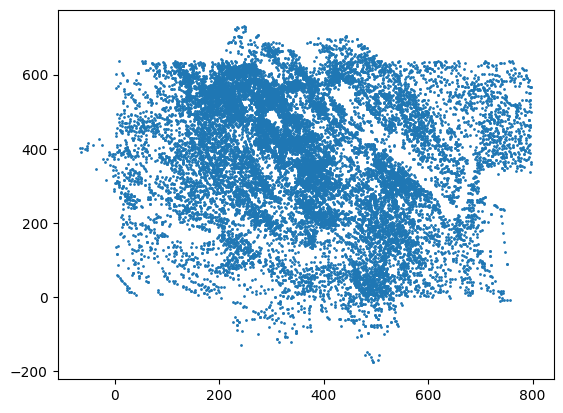

In [61]:
_, _, _ = create_sparse_map(graf_images_gray, 0.05, 1000, True)

## Ground Truth Generation

In [62]:
def generate_comparison_table(data, titles, thresh=0.05, n_iter=1000):
    comparison_table = []
    
    for idx, (images, H_gt) in enumerate(data):
        estimated_points, estimated_points_per_image, reference_image_number = create_sparse_map(images, thresh, n_iter)
        sift_features = sift_extraction(images)

        gt_points = np.empty((2,0))

        if reference_image_number == 1:
            reference_keypoints = np.array([kp.pt for kp in sift_features[reference_image_number-1][0]]).T
            gt_points = np.hstack([gt_points, reference_keypoints])
            
            for i in range(1,len(images)):
                pts = np.array([kp.pt for kp in sift_features[i][0]]).T
                global_pts = np.linalg.inv(H_gt[i-1]) @ np.vstack([pts, np.ones(pts.shape[1])])
                global_pts = global_pts[:2] / global_pts[2]
                gt_points = np.hstack([gt_points, global_pts])
        else:
            points_in_image_one = np.empty((2,0))
            pts_img0 = np.array([kp.pt for kp in sift_features[0][0]]).T
            points_in_image_one = np.hstack([points_in_image_one, pts_img0])
            
            for i in range(1,len(images)):
                pts = np.array([kp.pt for kp in sift_features[i][0]]).T
                global_pts = np.linalg.inv(H_gt[i-1]) @ np.vstack([pts, np.ones(pts.shape[1])])
                global_pts = global_pts[:2] / global_pts[2]
                points_in_image_one = np.hstack([points_in_image_one, global_pts])

            global_pts = H_gt[reference_image_number - 2] @ np.vstack([points_in_image_one, np.ones(points_in_image_one.shape[1])])
            global_pts = global_pts[:2] / global_pts[2]
            gt_points = np.hstack([gt_points, global_pts])

        comparison_table.append((gt_points, estimated_points, reference_image_number, images, thresh, n_iter))

    return comparison_table

In [78]:
def display_comparison_table(comparison_table, dataset_titles, show_plot=False, show_overlay=False):
    for idx, title in enumerate(dataset_titles):
        gt_points, estimated_points, ref_num, images, thresh, n_iter = comparison_table[idx]
        ref_idx = ref_num - 1
        thresh_str = str(thresh).replace('.', '-')

        if show_overlay:
            h, w = images[ref_idx].shape[:2]
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            ax.set_xlim(0, w)
            ax.set_ylim(h, 0)
            ax.imshow(images[ref_idx], cmap='gray')
            ax.scatter(estimated_points[0], estimated_points[1], s=0.6, alpha=0.3, c='red', label='Estimated')
            ax.scatter(gt_points[0], gt_points[1], s=0.6, alpha=0.3, c='blue', label='GT')
            ax.legend(markerscale=5)
            ax.set_title(f"Overlay on reference image {ref_idx} from {title}")
            plt.tight_layout()
            if show_plot:
                plt.show()
            else:
                plt.savefig(f"figs/{title}/{thresh_str}_{n_iter}_overlay.svg")
                plt.close()
        else:
            fig, axes = plt.subplots(2, 2, figsize=(12, 10))

            axes[0, 0].scatter(estimated_points[0], estimated_points[1], s=1)
            axes[0, 0].invert_yaxis()
            axes[0, 0].set_title(f"SFM point cloud with reference image {ref_idx} from {title}")

            axes[0, 1].scatter(gt_points[0], gt_points[1], s=1)
            axes[0, 1].invert_yaxis()
            axes[0, 1].set_title(f"Ground truth point cloud with reference image {ref_idx} from {title}")

            other_indices = [i for i in range(len(images)) if i != ref_idx]
            other_index = np.random.choice(other_indices)
            sample_indices = sorted([ref_idx, other_index])

            for col, i in enumerate(sample_indices):
                axes[1, col].imshow(images[i], cmap='gray')
                axes[1, col].set_title(f"Image {i}" + (" (reference)" if i == ref_idx else ""))

            plt.tight_layout()
            if show_plot:
                plt.show()
            else:
                plt.savefig(f"figs/{title}/{thresh_str}_{n_iter}.svg")
                plt.close()

In [79]:
def calculate_residuals(comparison_table, dataset_titles, return_df=True):
    rows = []
    for idx, title in enumerate(dataset_titles):
        gt_points, estimated_points, ref_num, _, thresh, n_iter = comparison_table[idx]
        residuals = np.linalg.norm(estimated_points - gt_points, axis=0)
        avg_residual = residuals.sum() / gt_points.shape[1]
        rows.append({'dataset': title, 'thresh': thresh, 'n_iter': n_iter, 'avg_residual': avg_residual})
        if not return_df:
            if idx == 0:
                print(f"Hyperparameters used are thresh={thresh}, n_iter={n_iter}")
                print("=" * 20)
                
            print(f"Average residual for dataset {title} is: {avg_residual:.4f}")
            
    return rows
    

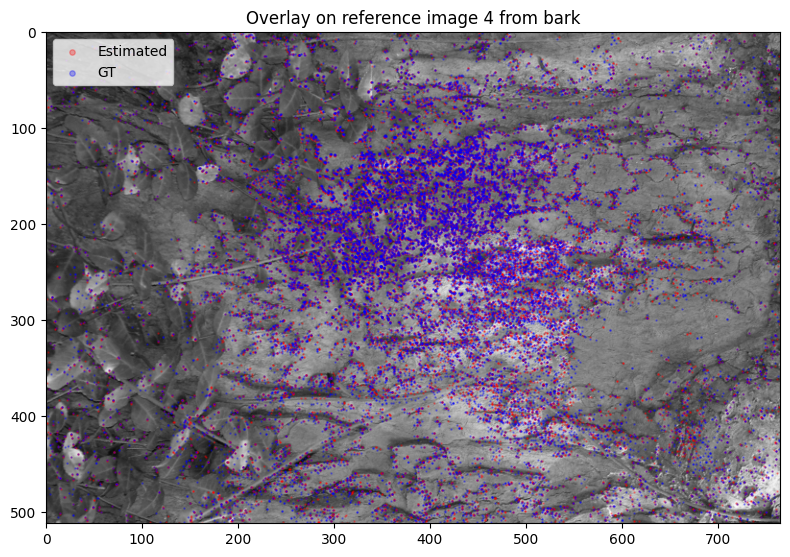

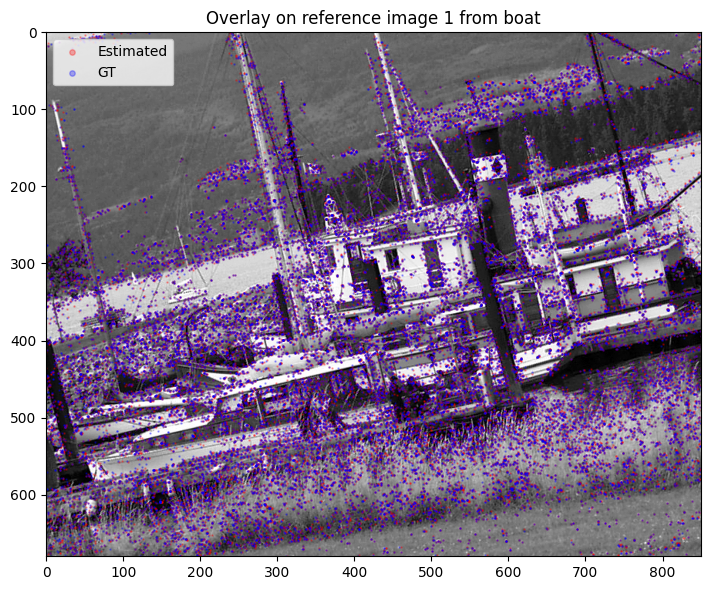

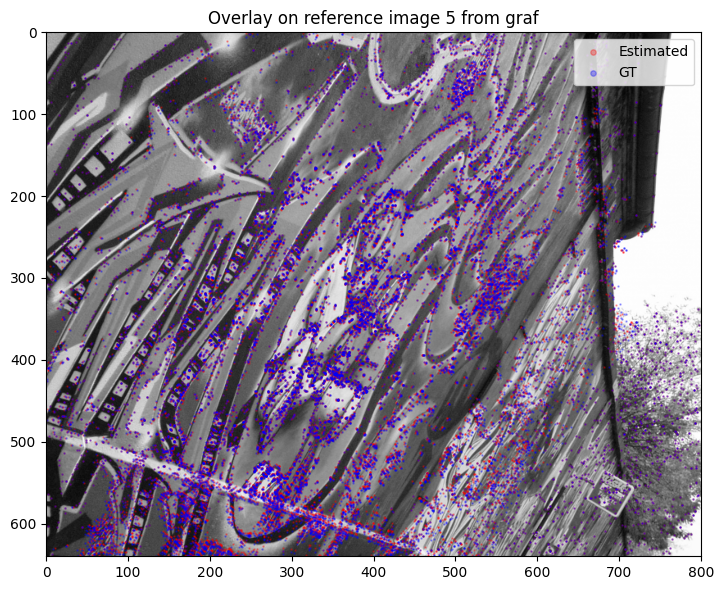

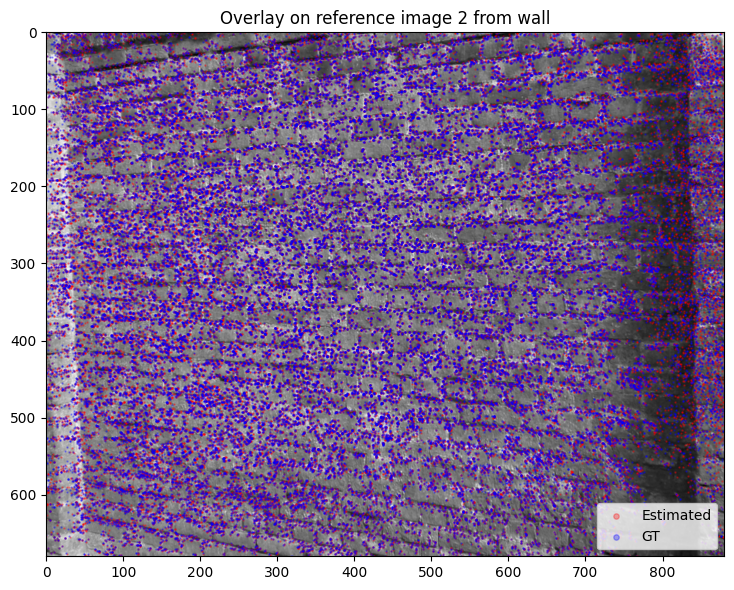

Hyperparameters used are thresh=0.0001, n_iter=1000
Average residual for dataset bark is: 3.2422
Average residual for dataset boat is: 6.0047
Average residual for dataset graf is: 1.5495
Average residual for dataset wall is: 2.2057


In [85]:
titles = ["bark", "boat", "graf", "wall"]
comparison_table = generate_comparison_table(data, titles, thresh=0.0001, n_iter=1000)
display_comparison_table(comparison_table, titles, show_plot=True, show_overlay=True)
_ = calculate_residuals(comparison_table, titles, False)

## Experimental Results
This section generates the experimental results

In [80]:
def run_grid_experiments(thresholds, n_iterations, data, titles):
    A, B = np.meshgrid(thresholds, n_iterations)
    pairs = np.stack([A.ravel(), B.ravel()], axis=1)

    all_rows = []
    for (thresh, n_iter) in tqdm(pairs, desc="Grid search"):
        comparison_table = generate_comparison_table(data, titles, thresh, int(n_iter))
        display_comparison_table(comparison_table, titles, show_plot=False)
        all_rows.extend(calculate_residuals(comparison_table, titles))

    return pd.DataFrame(all_rows)

In [81]:
thresholds = np.logspace(1, -5, num=7)
n_iterations = np.logspace(2, 4, num=3)
results = run_grid_experiments(thresholds, n_iterations, data, titles)

Grid search: 100%|██████████████████████████████| 21/21 [11:09<00:00, 31.90s/it]


In [82]:
def display_results(results_df):
      # Best and worst per dataset
      best = results_df.loc[results_df.groupby('dataset')['avg_residual'].idxmin()]
      worst = results_df.loc[results_df.groupby('dataset')['avg_residual'].idxmax()]

      print("Best hyperparameters per dataset:")
      print(best[['dataset', 'thresh', 'n_iter', 'avg_residual']].to_string(index=False))

      print("\nWorst hyperparameters per dataset:")
      print(worst[['dataset', 'thresh', 'n_iter', 'avg_residual']].to_string(index=False))

      # Full grid: one row per (thresh, n_iter), one column per dataset
      print("\nFull results grid:")
      pivot = results_df.pivot_table(
          index=['thresh', 'n_iter'],
          columns='dataset',
          values='avg_residual'
      ).round(4)
      print(pivot.to_string())

In [83]:
display_results(results)

Best hyperparameters per dataset:
dataset  thresh  n_iter  avg_residual
   bark 0.00001    1000      3.130409
   boat 0.00010   10000      5.933819
   graf 0.00001     100      1.038210
   wall 0.00001    1000      1.645263

Worst hyperparameters per dataset:
dataset  thresh  n_iter  avg_residual
   bark     1.0   10000   1525.181475
   boat     1.0     100   1323.025233
   graf     1.0     100   1218.542414
   wall     1.0    1000   2628.963186

Full results grid:
dataset               bark       boat       graf       wall
thresh   n_iter                                            
0.00001  100        3.2212     6.5595     1.0382     1.7712
         1000       3.1304     6.0593     1.4267     1.6453
         10000      3.2229     6.2859     1.4296     1.7357
0.00010  100        3.2987     6.6813     2.1149     2.4517
         1000       3.2655     7.1806     1.4863     2.6574
         10000      3.3479     5.9338     1.3680     2.8389
0.00100  100        3.3771    10.5577     2.0517  